# Lecture 1 Demo: Foundations of Clustering with K-Means

### Companion Notebook to "Foundations of Clustering and Density Estimation"
### Objective:
 - Load the Iris dataset and treat it as an Unsupervised problem (hiding labels)
 - Visualize the difference between Classes (Supervised) and Clusters (Unsupervised)
 - Implement K-Means to find prototypes ($m_i$) and minimize Reconstruction Error
 - Evaluate the model using the Elbow Method and Silhouette Coefficient

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

## Imports and Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Configure plotting style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded.")

Libraries loaded.


## Loading the Data (Simulating Unsupervised Learning)

In Supervised Learning, we have the dataset $\mathcal{X}=\{x^t, r^t\}$ where $r^t$ are the labels8.
In Unsupervised Learning, we only have $\mathcal{X}=\{x^t\}$. We must drop the labels to let the "data speak for itself"

In [3]:
# Load Iris dataset
iris = datasets.load_iris()
X = iris.data
y = iris.target # These are the 'r' labels we usually don't have in clustering
feature_names = iris.feature_names

# Create a DataFrame for easier manipulation
df = pd.DataFrame(X, columns=feature_names)

# For visualization purposes, we will focus on two specific features:
# Sepal Length vs Petal Length (Features 0 and 2)
# This allows us to replicate the 2D plots seen in the slides[cite: 53].
X_2d = X[:, [0, 2]] 

print("Data loaded. Shape:", X_2d.shape)
print("Note: In a real clustering scenario, we would NOT know 'y'.")

Data loaded. Shape: (150, 2)
Note: In a real clustering scenario, we would NOT know 'y'.


## Visualization: Classes vs. Clusters

This section mirrors the slide "Classes vs. Clusters"
 - Left: What the Algorithm sees (No Labels, just structure) $\rightarrow$ Clusters
 - Right: The Ground Truth (The actual species) $\rightarrow$ Classes

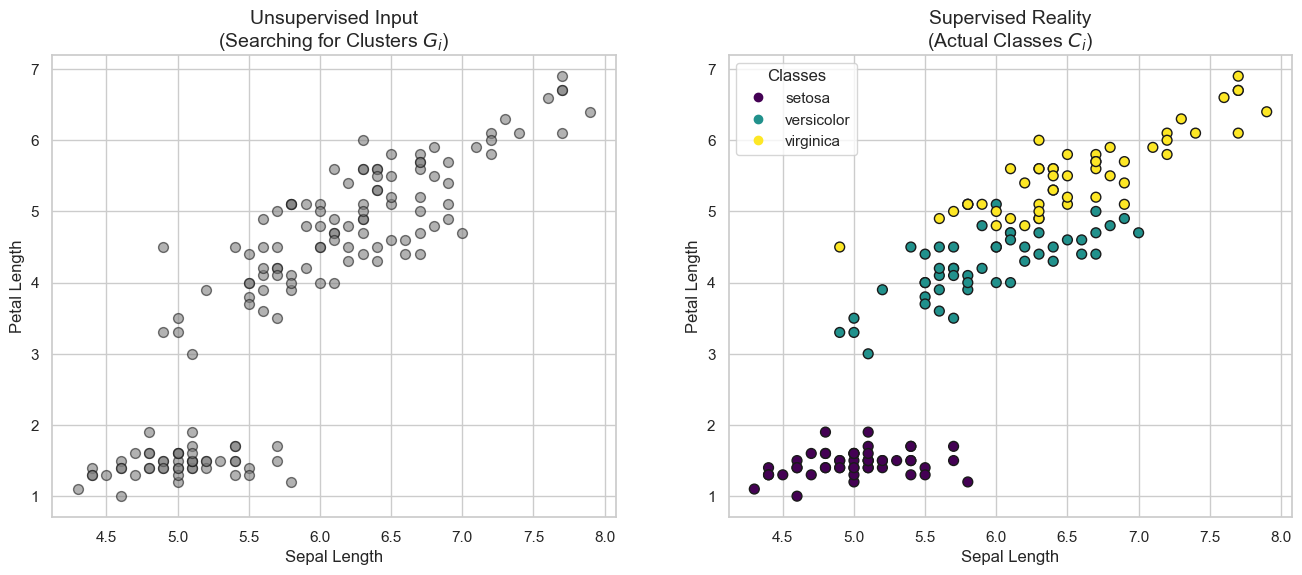

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Unsupervised View (What K-Means sees)
axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c='gray', edgecolor='k', s=50, alpha=0.6)
axes[0].set_title('Unsupervised Input\n(Searching for Clusters $G_i$)', fontsize=14)
axes[0].set_xlabel('Sepal Length')
axes[0].set_ylabel('Petal Length')

# Plot 2: Supervised View (Ground Truth)
scatter = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='viridis', edgecolor='k', s=50)
axes[1].set_title('Supervised Reality\n(Actual Classes $C_i$)', fontsize=14)
axes[1].set_xlabel('Sepal Length')
axes[1].set_ylabel('Petal Length')

# Add legend for classes
handles, _ = scatter.legend_elements()
legend1 = axes[1].legend(handles, iris.target_names, title="Classes")

plt.show()

## Implementing K-Means

We will look for $k=3$ clusters. The algorithm will attempt to find 3 Reference Vectors (prototypes) $m_i$ that minimize the distance to the data points

The objective is to minimize the Reconstruction Error:$$E = \sum_t \sum_i b_i^t ||x^t - m_i||$$

In [5]:
# Initialize K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# Fit the model to the data (Finding the means)
kmeans.fit(X_2d)

# Extract the results
# The 'centroids' are the reference vectors 'm_i' [cite: 30]
centroids = kmeans.cluster_centers_
# The 'labels' are the assignments 'b_i'
labels = kmeans.labels_

print("Cluster Centers (Prototypes):\n", centroids)

Cluster Centers (Prototypes):
 [[6.83902439 5.67804878]
 [5.00784314 1.49215686]
 [5.87413793 4.39310345]]


## Visualizing the Result (Prototypes)

We visualize the assigned clusters and plot the computed Centers ($m_i$) as large red 'X's. This visualizes the result of the iterative process described in the slides

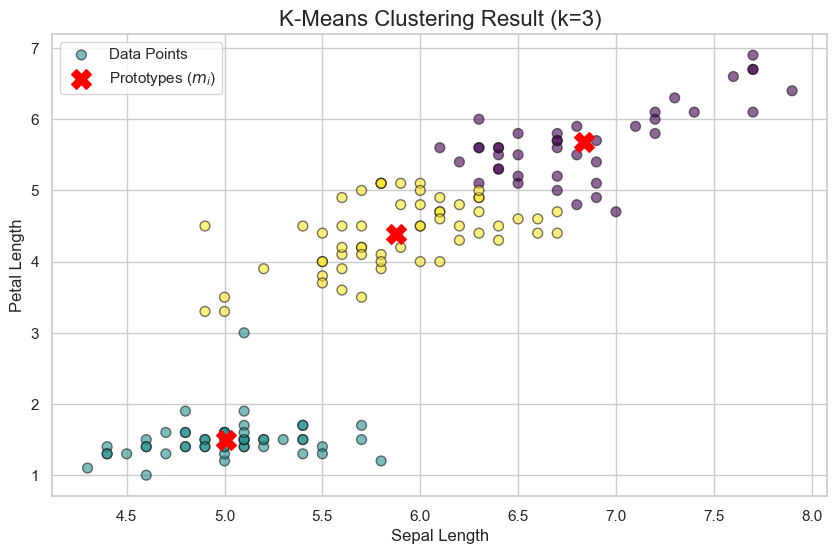

In [6]:
plt.figure(figsize=(10, 6))

# Plot the data points colored by their predicted cluster
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='viridis', marker='o', edgecolor='k', s=50, alpha=0.6, label='Data Points')

# Plot the centroids
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Prototypes ($m_i$)')

plt.title('K-Means Clustering Result (k=3)', fontsize=16)
plt.xlabel('Sepal Length')
plt.ylabel('Petal Length')
plt.legend()
plt.show()

## Choosing K: The Elbow Method

If we didn't know there were 3 species, how would we choose $k$?
We use the Elbow Method. We plot the Inertia (Scikit-Learn's term for Reconstruction Error) against $k$. We look for the point where the error reduction slows down (the "elbow")

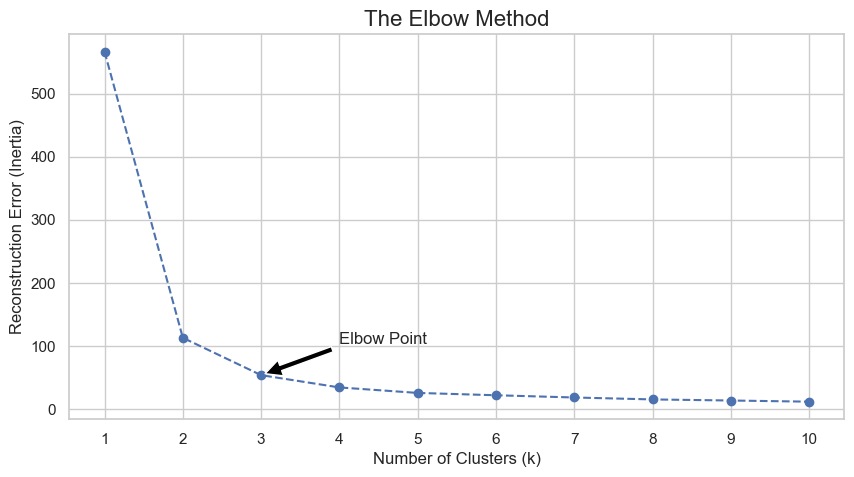

In [7]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_2d)
    # .inertia_ is exactly the Reconstruction Error sum defined in 
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.title('The Elbow Method', fontsize=16)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Reconstruction Error (Inertia)')
plt.xticks(k_range)
plt.grid(True)

# Highlight the elbow at k=3
plt.annotate('Elbow Point', xy=(3, inertia[2]), xytext=(4, inertia[2]+50),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

Note: This one wasn't discuss in the Lecture, but its pretty simmilar


**Instead** of The _Reduction in Total Variance_ in the y-axis (which increases while k increases), We here are graphing _Reconstruction Error_ in the y-axis (whcih decreases while k increases)

Instead of looking at the "Error" (Inertia) going down, we can look at **the Explained Variance** going up.
 - Total Variance: The variance of the entire dataset (Inertia at $k=1$)
 - Explained Variance: How much of that spread is captured by our clusters?
 - Goal: We want high explained variance with a low $k$. The "elbow" shows where adding more clusters stops giving us significant information gain

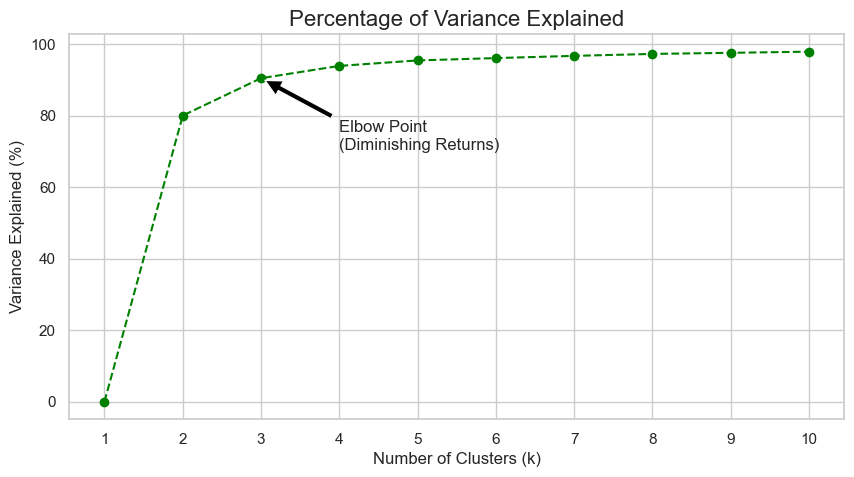

In [8]:
# Calculate Total Sum of Squares (TSS) - Inertia at k=1
# This represents the total variance in the data
km_total = KMeans(n_clusters=1, random_state=42, n_init=10)
km_total.fit(X_2d)
total_inertia = km_total.inertia_

explained_variance = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_2d)
    
    # Calculate % of Variance Explained
    # (Total Variance - Within Cluster Variance) / Total Variance
    variance_ratio = 100 * (total_inertia - km.inertia_) / total_inertia
    explained_variance.append(variance_ratio)

plt.figure(figsize=(10, 5))
plt.plot(k_range, explained_variance, marker='o', linestyle='--', color='green')
plt.title('Percentage of Variance Explained', fontsize=16)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Variance Explained (%)')
plt.xticks(k_range)
plt.grid(True)

# Highlight the elbow at k=3 (Point of diminishing returns)
# Note: At k=1, variance explained is 0%. At k=3, it jumps significantly.
elbow_y = explained_variance[2] # Index 2 is k=3
plt.annotate('Elbow Point\n(Diminishing Returns)', xy=(3, elbow_y), xytext=(4, elbow_y-20),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

## Evaluation: Silhouette Coefficient

We can also use the Silhouette Coefficient to check how dense and well-separated the clusters are
 - Score close to +1: Dense, well-separated
 - Score close to 0: Overlapping

In [9]:
# Calculate Silhouette Score for k=3
score = silhouette_score(X_2d, labels)

print(f"Silhouette Coefficient for k=3: {score:.3f}")

# Compare with other k values
print("\nComparing Silhouette Scores:")
for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_2d)
    s_score = silhouette_score(X_2d, labels_k)
    print(f"k={k}: {s_score:.3f}")

Silhouette Coefficient for k=3: 0.589

Comparing Silhouette Scores:
k=2: 0.710
k=3: 0.589
k=4: 0.565
k=5: 0.558


## Knowledge Extraction: Cluster Purity

Clustering is often used for Knowledge Extraction. Let's see if the clusters we found actually correspond to the biological species (Classes)

In [10]:
# Create a DataFrame to compare Labels (Unsupervised) vs Species (Supervised)
df_compare = pd.DataFrame({'Cluster_ID': labels, 'True_Species': y})

# Crosstab (Confusion Matrix)
ct = pd.crosstab(df_compare['Cluster_ID'], df_compare['True_Species'])
ct.columns = iris.target_names
print("Cross-tabulation of Clusters found vs Actual Species:\n")
print(ct)

Cross-tabulation of Clusters found vs Actual Species:

            setosa  versicolor  virginica
Cluster_ID                               
0                0           4         37
1               50           1          0
2                0          45         13


As we can see that one cluster perfectly isolates Setosa. The other two clusters might have some overlap between Versicolor and Virginica, which reflects the visual overlap we saw in the scatter plot. This confirms that K-Means successfully extracted structural knowledge about the data